- **학습 목표**: 차원 축소가 "무손실이 아니라는 것"을 직접 눈으로 확인한다.
- **핵심 개념**: `inverse_transform`은 k개 주성분으로 압축한 결과를 원래 차원으로 되돌립니다. 하지만 버린 (64-k)개 방향의 정보는 복구되지 않으므로 오차가 남습니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_digits

52.98265894706471


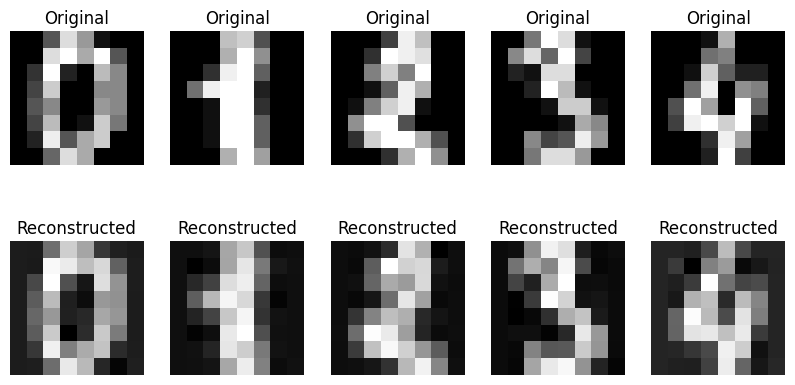

In [15]:
def reconstruct_and_compare(X_scaled,digits,scaler ,k=2):
  """
  요구사항:
  - PCA(n_components=k)로 fit_transform → inverse_transform으로 복원.
  - 원본과 복원본 사이 MSE를 계산해 출력.
  - 상위 5개 샘플에 대해 (원본 8x8 이미지, 복원된 8x8 이미지)를 2행 5열로 나란히 그려
  'week02/reconstruction_comparison.png'로 저장.
  - 주의: 복원된 값은 스케일된 공간에 있으므로 원본 픽셀값과 완전히 같지는 않다.
  시각 비교가 목적이라면 스케일을 되돌리는 것도 고려해볼 것.
  """
  pca = PCA(n_components=k)
  X_pca = pca.fit_transform(X_scaled)
  X_inversed = pca.inverse_transform(X_pca)
  X_inversed = scaler.inverse_transform(X_inversed)
  #MSE
  mse = mean_squared_error(X_inversed, X_scaled)
  print(mse)
  plt.figure(figsize=(10, 5))
  for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(digits[i].reshape(8, 8), cmap='gray')
    plt.title('Original')
    plt.axis('off')
    plt.subplot(2, 5, i+6)
    plt.imshow(X_inversed[i].reshape(8, 8), cmap='gray')
    plt.title('Reconstructed')
    plt.axis('off')
  plt.show()
data = load_digits()
X, y = data.data, data.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
reconstruct_and_compare(X_scaled,X,scaler, 40)